# Balance Classes + Soft Balanced Demographic Groups

This notebook will combine class balancing and soft demographic group balancing for further analysis.

In [1]:
# Load the soft-balanced demographic variable training dataset
import pandas as pd

df = pd.read_csv('balance_demographic_variable_training_dataset.csv')
print('Soft-balanced demographic variable training dataset loaded. Shape:', df.shape)
df.head()

Soft-balanced demographic variable training dataset loaded. Shape: (33390, 39)


,number_inpatient,time_in_hospital,number_emergency,number_outpatient,num_medications,num_lab_procedures,diabetesMed,insulin,metformin,admission_type_id,...,diag_1_Respiratory,diag_2_Circulatory,diag_2_Diabetes,diag_2_Digestive,diag_2_Genitourinary,diag_2_Injury,diag_2_Musculoskeletal,diag_2_Neoplasms,diag_2_Other,diag_2_Respiratory
0,0,2,0,0,2,25,0,0,0,2,...,0,0,0,0,0,0,0,0,0,1
1,0,5,0,0,11,65,1,3,0,1,...,0,0,0,0,0,0,0,0,1,0
2,0,3,0,0,4,21,1,2,0,3,...,0,0,0,0,0,0,0,0,1,0
3,0,3,0,0,10,31,1,2,0,1,...,1,0,1,0,0,0,0,0,0,0
4,0,2,0,0,6,39,1,1,0,1,...,0,0,0,1,0,0,0,0,0,0


Class distribution:
readmitted
0    29606
1     3784
Name: count, dtype: int64


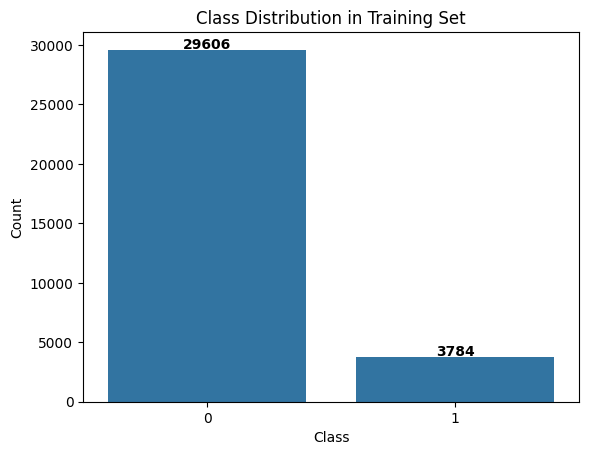

In [2]:
# Show and plot class distribution
import matplotlib.pyplot as plt
import seaborn as sns

class_col = 'readmitted'  # update if your target column is different
class_counts = df[class_col].value_counts()
print('Class distribution:')
print(class_counts)

ax = sns.barplot(x=class_counts.index, y=class_counts.values)
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 50, str(v), color='black', ha='center', fontweight='bold')
plt.title('Class Distribution in Training Set')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [3]:
# Balance the classes: downsample class 0 to match class 1 (3784 each)
from sklearn.utils import resample

# Separate majority and minority classes
df_majority = df[df[class_col] == 0]
df_minority = df[df[class_col] == 1]

# Downsample majority class
df_majority_downsampled = resample(df_majority, 
                                         replace=False,    # sample without replacement
                                         n_samples=len(df_minority), # to match minority class
                                         random_state=42)

# Combine minority class with downsampled majority class
df_balanced = pd.concat([df_majority_downsampled, df_minority])

# Shuffle the resulting dataframe
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print('Balanced class distribution:')
print(df_balanced[class_col].value_counts())

Balanced class distribution:
readmitted
1    3784
0    3784
Name: count, dtype: int64


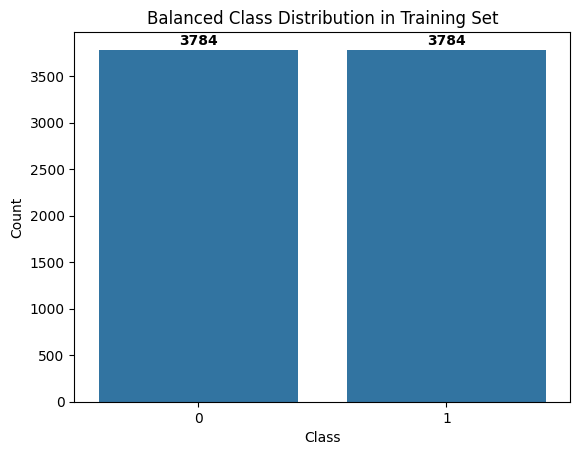

In [4]:
# Visualize the balanced class distribution
import matplotlib.pyplot as plt
import seaborn as sns

balanced_counts = df_balanced[class_col].value_counts()
ax = sns.barplot(x=balanced_counts.index, y=balanced_counts.values)
for i, v in enumerate(balanced_counts.values):
    ax.text(i, v + 50, str(v), color='black', ha='center', fontweight='bold')
plt.title('Balanced Class Distribution in Training Set')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [5]:
# Save the balanced dataset to CSV
df_balanced.to_csv('Balanceclasses+softbalanced_demographic_groups.csv', index=False)
print('Balanced dataset saved as Balanceclasses+softbalanced_demographic_groups.csv')

Balanced dataset saved as Balanceclasses+softbalanced_demographic_groups.csv


# Summary and Explanation

In this notebook, we performed the following steps:
1. **Loaded the soft-balanced demographic variable training dataset**: This dataset was previously balanced to ensure fair representation across demographic groups (e.g., age, race, gender) using a soft balancing approach.
2. **Explored the initial class distribution**: We visualized the distribution of the target variable (`readmitted`) to observe class imbalance.
3. **Balanced the classes**: We downsampled the majority class (class 0) to match the number of samples in the minority class (class 1), resulting in an equal number of samples for both classes (3784 each).
4. **Visualized the balanced class distribution**: We confirmed the balancing by plotting the new class distribution.
5. **Saved the final balanced dataset**: The resulting dataset, which is both soft-balanced for demographic groups and strictly balanced for the target class, was saved as `Balanceclasses+softbalanced_demographic_groups.csv`.

This dataset is now ready for fair and unbiased machine learning experiments, ensuring that both class and demographic distributions are appropriately represented.